# Stock Price Movement Prediction using Machine Learning

This project predicts whether a stock price will increase or decrease on the next trading day using machine learning models and technical indicators derived from historical stock data.

## 1. Import Required Libraries

In this section we import the Python libraries used for data analysis, visualization, and machine learning.

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report, r2_score,accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

## 2. Load the Dataset

The dataset contains historical stock market information including opening price, closing price, highest price, lowest price, and trading volume.

In [134]:
df = pd.read_csv("Microsoft_Stock.csv")

print(df.head())

print(df.tail())

                Date   Open   High    Low  Close    Volume
0  4/1/2015 16:00:00  40.60  40.76  40.31  40.72  36865322
1  4/2/2015 16:00:00  40.66  40.74  40.12  40.29  37487476
2  4/6/2015 16:00:00  40.34  41.78  40.18  41.55  39223692
3  4/7/2015 16:00:00  41.61  41.91  41.31  41.53  28809375
4  4/8/2015 16:00:00  41.48  41.69  41.04  41.42  24753438
                    Date    Open    High     Low   Close    Volume
1506  3/25/2021 16:00:00  235.30  236.94  231.57  232.34  34061853
1507  3/26/2021 16:00:00  231.55  236.71  231.55  236.48  25479853
1508  3/29/2021 16:00:00  236.59  236.80  231.88  235.24  25227455
1509  3/30/2021 16:00:00  233.53  233.85  231.10  231.85  24792012
1510  3/31/2021 16:00:00  232.91  239.10  232.39  235.77  43623471


## 3. Exploratory Data Analysis

Exploratory data analysis helps us understand the structure of the dataset, detect patterns, and identify any anomalies in the data.

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1511 entries, 0 to 1510
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1511 non-null   object 
 1   Open    1511 non-null   float64
 2   High    1511 non-null   float64
 3   Low     1511 non-null   float64
 4   Close   1511 non-null   float64
 5   Volume  1511 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 71.0+ KB


In [136]:
df.describe()

,Open,High,Low,Close,Volume
count,1511.000000,1511.000000,1511.000000,1511.000000,1.511000e+03
mean,107.385976,108.437472,106.294533,107.422091,3.019863e+07
std,56.691333,57.382276,55.977155,56.702299,1.425266e+07
min,40.340000,40.740000,39.720000,40.290000,1.016120e+05
25%,57.860000,58.060000,57.420000,57.855000,2.136213e+07
50%,93.990000,95.100000,92.920000,93.860000,2.662962e+07
75%,139.440000,140.325000,137.825000,138.965000,3.431962e+07
max,245.030000,246.130000,242.920000,244.990000,1.352271e+08


In [137]:
print(df.shape)

print(df.columns)

(1511, 6)
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')


### Checking for missing values

In [138]:
df.isnull()

,Date,Open,High,Low,Close,Volume
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
1506,False,False,False,False,False,False
1507,False,False,False,False,False,False
1508,False,False,False,False,False,False
1509,False,False,False,False,False,False


#### The dataset was checked for missing values and none were found, so no imputation or removal was required.

In [139]:
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Date,Open,High,Low,Close,Volume
0,2015-04-01 16:00:00,40.60,40.76,40.31,40.72,36865322
1,2015-04-02 16:00:00,40.66,40.74,40.12,40.29,37487476
2,2015-04-06 16:00:00,40.34,41.78,40.18,41.55,39223692
3,2015-04-07 16:00:00,41.61,41.91,41.31,41.53,28809375
4,2015-04-08 16:00:00,41.48,41.69,41.04,41.42,24753438


In [140]:
df.sort_values(by="Date", ascending = True, inplace=True)
df.head()

,Date,Open,High,Low,Close,Volume
0,2015-04-01 16:00:00,40.60,40.76,40.31,40.72,36865322
1,2015-04-02 16:00:00,40.66,40.74,40.12,40.29,37487476
2,2015-04-06 16:00:00,40.34,41.78,40.18,41.55,39223692
3,2015-04-07 16:00:00,41.61,41.91,41.31,41.53,28809375
4,2015-04-08 16:00:00,41.48,41.69,41.04,41.42,24753438


In [141]:
df.duplicated().sum()

np.int64(0)

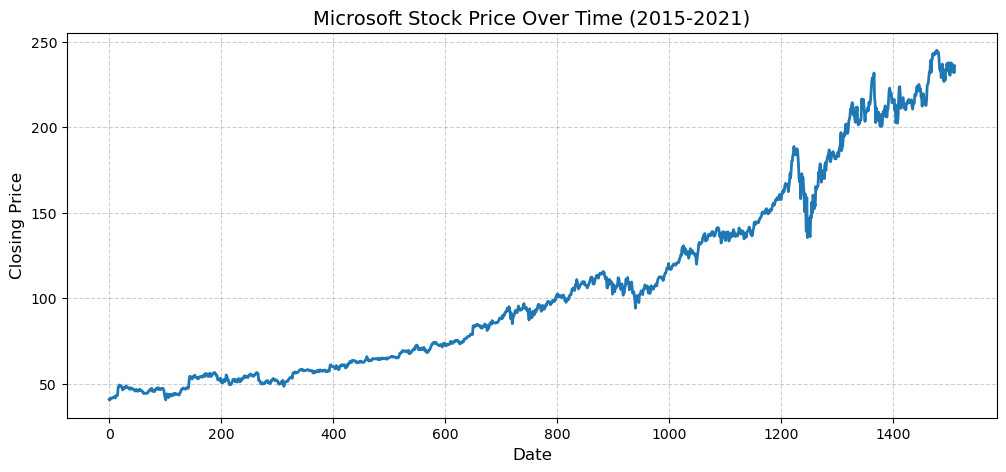

In [142]:
plt.figure(figsize=(12,5))

plt.plot(df.index, df['Close'], linewidth= 2)

plt.xlabel("Date", fontsize=12)
plt.ylabel("Closing Price", fontsize = 12)
plt.title("Microsoft Stock Price Over Time (2015-2021)", fontsize = 14)

plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

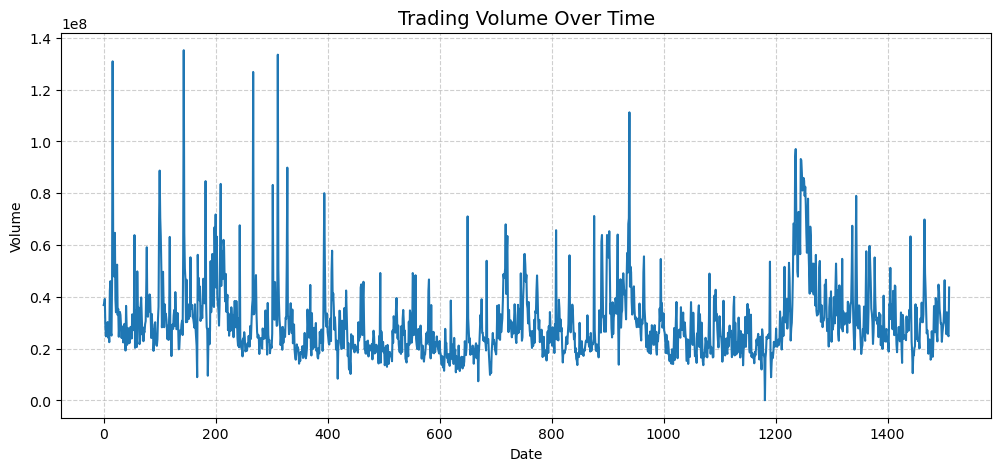

In [143]:
plt.figure(figsize=(12,5))

plt.plot(df.index, df["Volume"])

plt.title("Trading Volume Over Time", fontsize = 14)
plt.xlabel("Date")
plt.ylabel("Volume")

plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

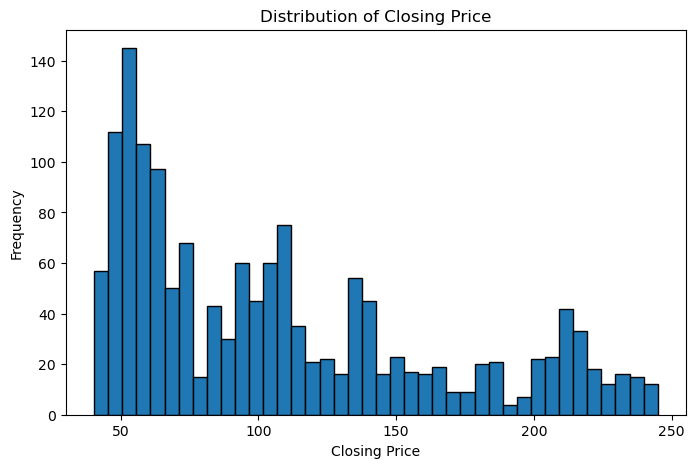

In [144]:
plt.figure(figsize=(8,5))

plt.hist(df["Close"], bins=40, edgecolor='black')

plt.title("Distribution of Closing Price")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")

plt.show()

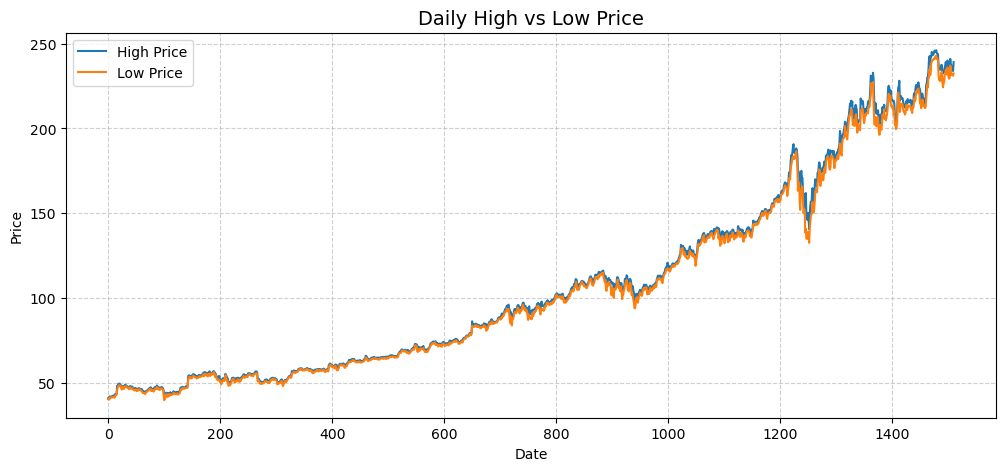

In [145]:
plt.figure(figsize=(12,5))

plt.plot(df.index, df["High"], label="High Price")
plt.plot(df.index, df["Low"], label="Low Price")

plt.title("Daily High vs Low Price", fontsize = 14)
plt.xlabel("Date")
plt.ylabel("Price")

plt.grid(True, linestyle="--", alpha=0.6)

plt.legend()

plt.show()

## 4. Feature Engineering

In this step, several technical indicators are created from the raw stock data. These indicators help capture trends, momentum, and volatility in the stock price.

In [146]:
# MA10 - Average closing price of the stock over the last 10 days, used to identify short-term trends.
# MA20 - Average closing price over the past 20 days, indicating medium-term price trends.
# MA50 - Average closing price over the past 50 days, commonly used to observe long-term trends.

df['MA10'] = df['Close'].rolling(window=10).mean()
df["MA20"] = df["Close"].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()

In [147]:
# EMA12 - Exponential moving average over 12 days, giving more weight to recent prices for faster trend detection.
# EMA26 - Exponential moving average over 26 days, used to identify longer trend movements

df["EMA12"] = df["Close"].ewm(span=12, adjust=False).mean()
df["EMA26"] = df["Close"].ewm(span=26, adjust=False).mean()

In [148]:
# MACD - Momentum indicator calculated as the difference between EMA12 and EMA26, used to detect trend changes.

df["MACD"] = df["EMA12"] - df["EMA26"]

In [149]:
# Daily_Return - Percentage change in closing price from one day to the next.

df["Daily_Return"] = df["Close"].pct_change()

In [150]:
# Momentum_5 - Difference between the current closing price and the closing price 5 days earlier, showing price momentum.

df["Momentum_5"] = df["Close"] - df["Close"].shift(5)

In [151]:
#Volatility_10 - Standard deviation of returns over the last 10 days, measuring how much the price fluctuates.

df["Volatility_10"] = df["Close"].rolling(window=10).std()

In [152]:
# Volume_Change - Percentage change in trading volume compared to the previous day.

df["Volume_Change"] = df["Volume"].pct_change()

In [153]:
# HL_Spread - Difference between the high and low price of the day, representing the intraday price range.

df["HL_Spread"] = df["High"] - df["Low"]

In [154]:
#Close_lag1 - Closing price of the previous trading day used as a lag feature.
#Close_lag2 - Closing price from two days earlier, capturing short-term price history.

df["Close_lag1"] = df["Close"].shift(1)
df["Close_lag2"] = df["Close"].shift(2)

In [155]:
#Return_lag1 - Daily return value from the previous day.
#Return_lag2 - Daily return value from two days before.

df["Return_lag1"] = df["Daily_Return"].shift(1)
df["Return_lag2"] = df["Daily_Return"].shift(2)

In [156]:
df.head()

,Date,Open,High,Low,Close,Volume,MA10,MA20,MA50,EMA12,...,MACD,Daily_Return,Momentum_5,Volatility_10,Volume_Change,HL_Spread,Close_lag1,Close_lag2,Return_lag1,Return_lag2
0,2015-04-01 16:00:00,40.60,40.76,40.31,40.72,36865322,NaN,NaN,NaN,40.720000,...,0.000000,NaN,NaN,NaN,NaN,0.45,NaN,NaN,NaN,NaN
1,2015-04-02 16:00:00,40.66,40.74,40.12,40.29,37487476,NaN,NaN,NaN,40.653846,...,-0.034302,-0.010560,NaN,NaN,0.016876,0.62,40.72,NaN,NaN,NaN
2,2015-04-06 16:00:00,40.34,41.78,40.18,41.55,39223692,NaN,NaN,NaN,40.791716,...,0.039727,0.031273,NaN,NaN,0.046315,1.60,40.29,40.72,-0.010560,NaN
3,2015-04-07 16:00:00,41.61,41.91,41.31,41.53,28809375,NaN,NaN,NaN,40.905298,...,0.095679,-0.000481,NaN,NaN,-0.265511,0.60,41.55,40.29,0.031273,-0.010560
4,2015-04-08 16:00:00,41.48,41.69,41.04,41.42,24753438,NaN,NaN,NaN,40.984483,...,0.129650,-0.002649,NaN,NaN,-0.140785,0.65,41.53,41.55,-0.000481,0.031273


In [157]:
df.isnull().sum()

Date              0
Open              0
High              0
Low               0
Close             0
Volume            0
MA10              9
MA20             19
MA50             49
EMA12             0
EMA26             0
MACD              0
Daily_Return      1
Momentum_5        5
Volatility_10     9
Volume_Change     1
HL_Spread         0
Close_lag1        1
Close_lag2        2
Return_lag1       2
Return_lag2       3
dtype: int64

In [158]:
df.dropna(inplace=True)

In [159]:
df.isnull().sum()

Date             0
Open             0
High             0
Low              0
Close            0
Volume           0
MA10             0
MA20             0
MA50             0
EMA12            0
EMA26            0
MACD             0
Daily_Return     0
Momentum_5       0
Volatility_10    0
Volume_Change    0
HL_Spread        0
Close_lag1       0
Close_lag2       0
Return_lag1      0
Return_lag2      0
dtype: int64

## 5. Target Variable Creation

The target variable represents the direction of the stock price movement on the next day.

- 1 → Stock price increases
- 0 → Stock price decreases

In [160]:
df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

## 6. Feature Selection

The following engineered features are selected as inputs for the machine learning models.

In [161]:
features = ["MA10","MA20","MA50","EMA12","EMA26","MACD","Daily_Return","Momentum_5","Volatility_10","Volume_Change","HL_Spread","Close_lag1","Close_lag2","Return_lag1","Return_lag2"]

X = df[features]
y = df["Target"]

## 7. Train-Test Split

The dataset is divided into training and testing sets. The training data is used to train the models, while the test data is used to evaluate their performance.

In [162]:
split = int(len(df)*0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

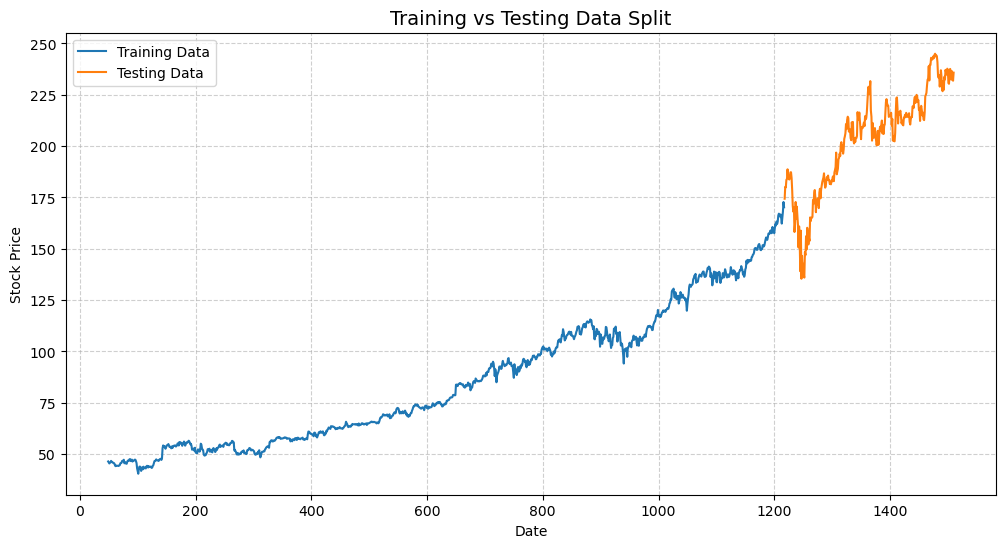

In [163]:
plt.figure(figsize=(12,6))

plt.plot(df.index[:split], df["Close"][:split], label="Training Data")
plt.plot(df.index[split:], df["Close"][split:], label="Testing Data")

plt.title("Training vs Testing Data Split", fontsize = 14)
plt.xlabel("Date")
plt.ylabel("Stock Price")

plt.grid(True, linestyle="--", alpha=0.6)

plt.legend()
plt.show()

## 8. Feature Scaling

Feature scaling ensures that all input variables are on a similar scale, which improves the performance of certain machine learning models.

In [164]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 9. Model Training and Model Evaluation

Three machine learning models are trained and compared:

- Logistic Regression
- Linear Regression
- Random Forest

The models are evaluated using classification metrics such as accuracy, precision, recall, and confusion matrix.

LOGISTIC REGRESSION MODEL

In [165]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, log_pred))

print(classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.5119453924914675
Confusion Matrix:
[[51 81]
 [62 99]]
              precision    recall  f1-score   support

           0       0.45      0.39      0.42       132
           1       0.55      0.61      0.58       161

    accuracy                           0.51       293
   macro avg       0.50      0.50      0.50       293
weighted avg       0.51      0.51      0.51       293



LINEAR REGRESSION MODEL

In [166]:
lin_model = LinearRegression()

lin_model.fit(X_train_scaled, y_train)

lin_pred = lin_model.predict(X_test_scaled)

lin_pred_class = (lin_pred > 0.5).astype(int)

print("Linear Regression Accuracy:", accuracy_score(y_test, lin_pred_class))

print("Confusion Matrix:")
print(confusion_matrix(y_test, lin_pred_class))

Linear Regression Accuracy: 0.49829351535836175
Confusion Matrix:
[[51 81]
 [66 95]]


In [167]:
print("MAE:", mean_absolute_error(y_test, lin_pred_class))

mse = mean_squared_error(y_test, lin_pred_class)
print("MSE:", mse)

rmse = np.sqrt(mse)
print("RMSE:", rmse)

print("R2 Score:", r2_score(y_test, lin_pred_class))

MAE: 0.5017064846416383
MSE: 0.5017064846416383
RMSE: 0.7083124202226291
R2 Score: -1.0266798418972334


RANDOM FOREST MODEL

In [168]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.5085324232081911
Confusion Matrix:
[[64 68]
 [76 85]]
              precision    recall  f1-score   support

           0       0.46      0.48      0.47       132
           1       0.56      0.53      0.54       161

    accuracy                           0.51       293
   macro avg       0.51      0.51      0.51       293
weighted avg       0.51      0.51      0.51       293



In [169]:
r2 = r2_score(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("R2 Score:", r2)
print("RMSE:", rmse)

R2 Score: -0.9853190287972899
RMSE: 0.7010474854043832


## Saving the Trained Model

In [170]:
import joblib

joblib.dump(log_model, "stock_prediction_model.pkl")

['stock_prediction_model.pkl']

## 10. Model Comparison

The performance of all trained models is compared to determine which model performs best for predicting stock movement.

In [171]:
log_acc = accuracy_score(y_test, log_pred)
lin_acc = accuracy_score(y_test, lin_pred_class)
rf_acc = accuracy_score(y_test, rf_pred)


In [172]:
print("Model Comparison")

results = pd.DataFrame({
"Model":["Logistic Regression","Linear Regression","Random Forest"],
"Accuracy":[log_acc, lin_acc, rf_acc]
})

results

Model Comparison


,Model,Accuracy
0,Logistic Regression,0.511945
1,Linear Regression,0.498294
2,Random Forest,0.508532


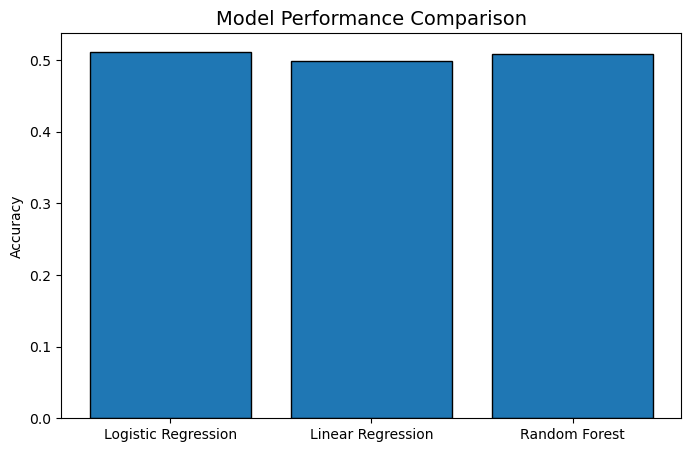

In [173]:
models = ["Logistic Regression","Linear Regression","Random Forest"]
scores = [log_acc, lin_acc, rf_acc]

plt.figure(figsize=(8,5))

plt.bar(models, scores, edgecolor='black')

plt.ylabel("Accuracy")
plt.title("Model Performance Comparison", fontsize = 14)

plt.show()

## 11. Visualization

Several visualizations are generated to better understand the data and the behavior of the trained models.

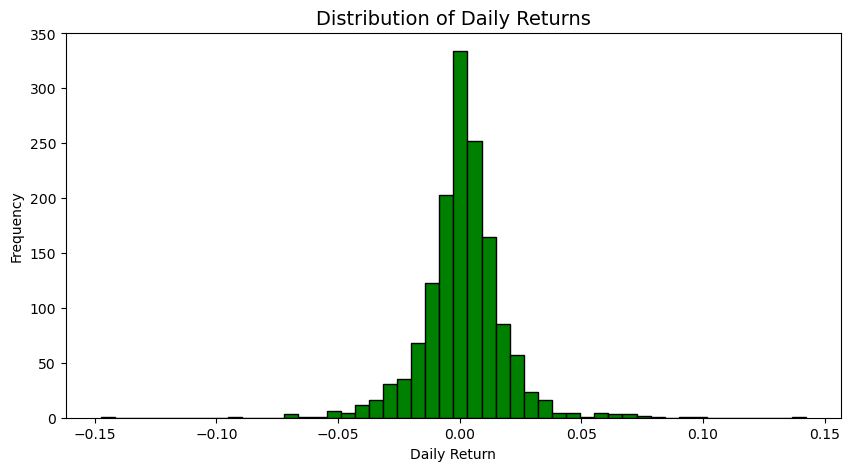

In [174]:
plt.figure(figsize=(10,5))

plt.hist(df['Daily_Return'], bins=50, color='green', edgecolor= 'black')

plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Returns", fontsize = 14)

plt.show()

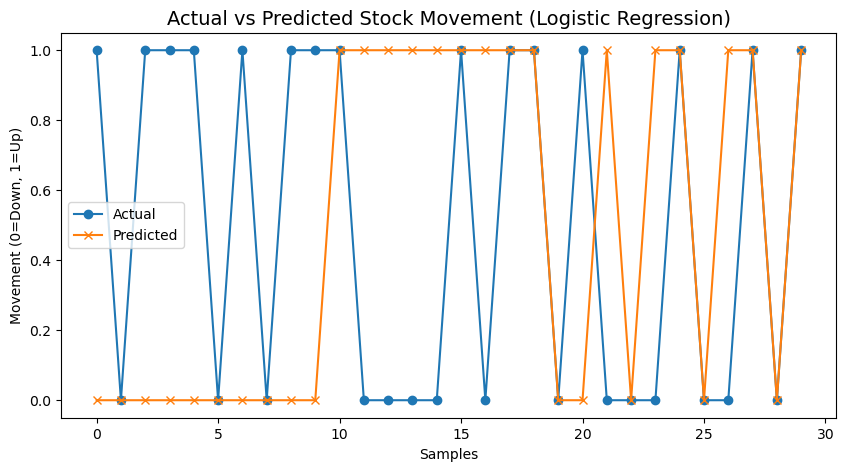

In [175]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:30], label="Actual", marker='o')
plt.plot(log_pred[:30], label="Predicted", marker='x')

plt.title("Actual vs Predicted Stock Movement (Logistic Regression)", fontsize = 14)
plt.xlabel("Samples")
plt.ylabel("Movement (0=Down, 1=Up)")

plt.legend()

plt.show()

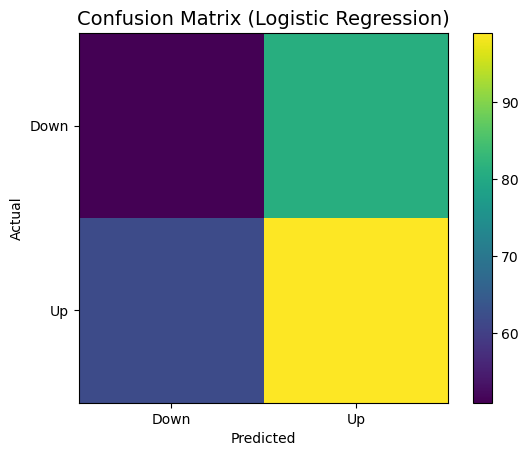

In [176]:
cm = confusion_matrix(y_test, log_pred)

plt.figure()

plt.imshow(cm)

plt.colorbar()

plt.xticks([0,1], ["Down","Up"])
plt.yticks([0,1], ["Down","Up"])

plt.title("Confusion Matrix (Logistic Regression)", fontsize = 14)
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

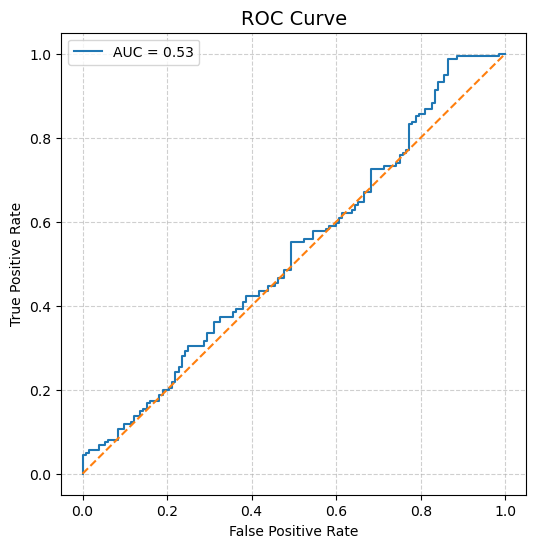

In [177]:
prob = log_model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.grid(True, linestyle="--", alpha=0.6)

plt.title("ROC Curve", fontsize = 14)
plt.legend()

plt.show()

Daily_Return     0.092440
Momentum_5       0.088059
Volume_Change    0.083661
Return_lag2      0.082496
MACD             0.076826
Return_lag1      0.074397
HL_Spread        0.074049
Volatility_10    0.073532
Close_lag1       0.056167
MA10             0.051703
EMA12            0.050724
Close_lag2       0.050586
MA50             0.050411
MA20             0.049449
EMA26            0.045499
dtype: float64


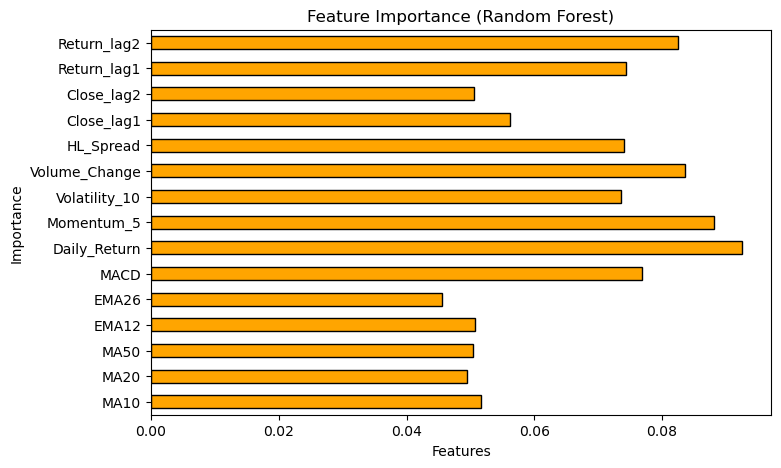

In [178]:
importance = pd.Series(rf_model.feature_importances_, index=features)

print(importance.sort_values(ascending=False))

plt.figure(figsize=(8,5))
importance.plot(kind='barh',color='orange', edgecolor = 'black')

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

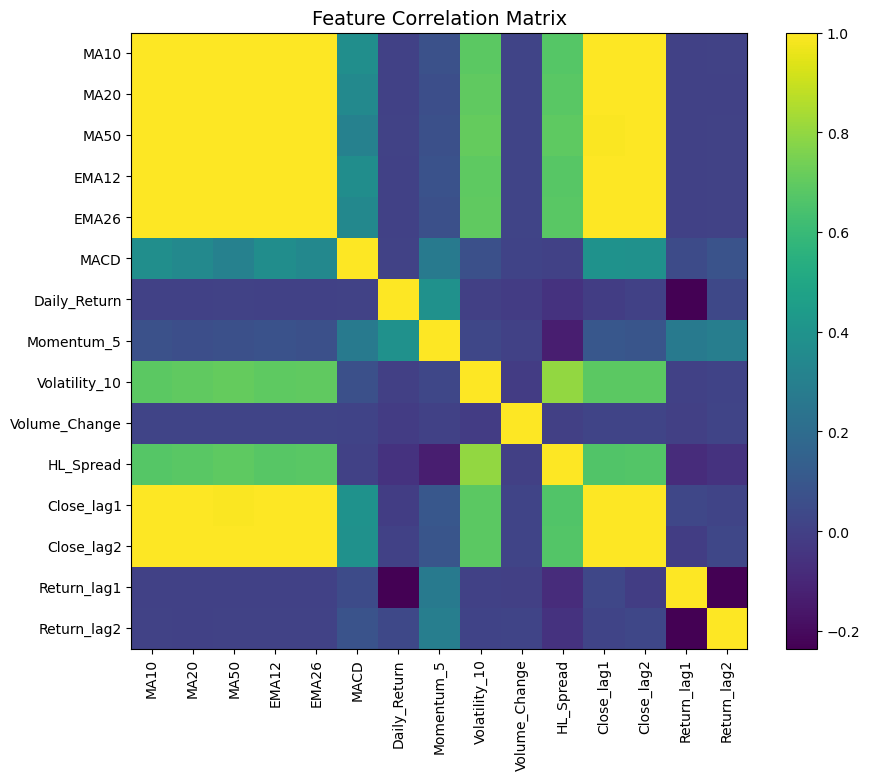

In [179]:
corr = df[features].corr()

plt.figure(figsize=(10,8))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(features)), features, rotation=90)
plt.yticks(range(len(features)), features)

plt.title("Feature Correlation Matrix", fontsize = 14)

plt.show()

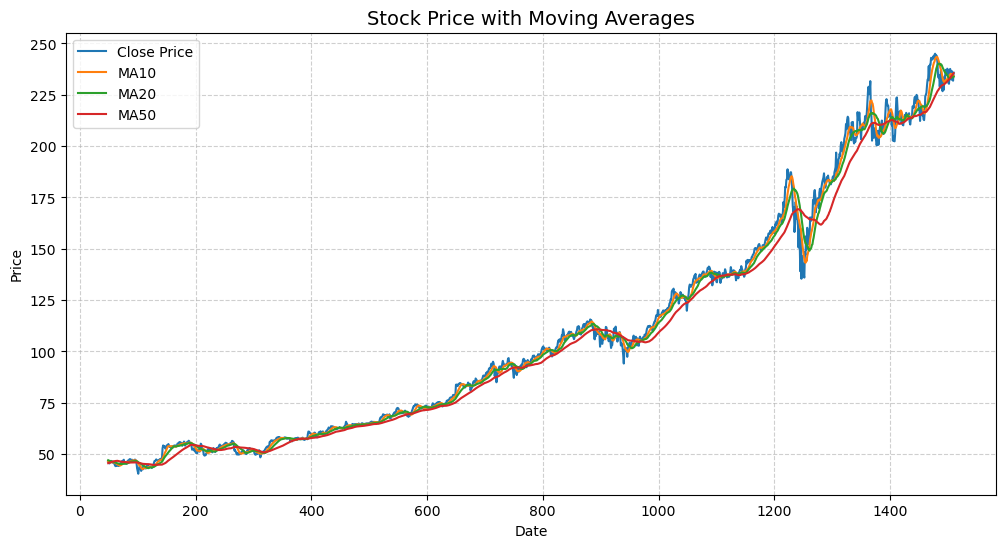

In [180]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df['Close'], label='Close Price')
plt.plot(df.index, df['MA10'], label='MA10')
plt.plot(df.index,df['MA20'], label='MA20')
plt.plot(df.index, df['MA50'], label='MA50')

plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Stock Price with Moving Averages", fontsize = 14)

plt.grid(True, linestyle="--", alpha=0.6)

plt.legend()

plt.show()

### Model Prediction Example

In [181]:
sample = X_test_scaled[0].reshape(1,-1)

prediction = log_model.predict(sample)

if prediction[0] == 1:
    print("Predicted Movement: UP")
else:
    print("Predicted Movement: DOWN")

Predicted Movement: DOWN


### Key Insights from the Analysis

1. Moving averages such as MA10, MA20, and MA50 helped capture short-term and long-term price trends.

2. Momentum and volatility indicators provided additional information about recent price behavior and market fluctuations.

3. Feature importance analysis from the Random Forest model showed that price-based indicators such as High, Low, and moving averages had a stronger influence on predictions.

4. The models achieved an accuracy of approximately 50–51%, indicating that predicting short-term stock price movement is highly challenging.

5. Financial markets are influenced by many external factors such as news events, investor sentiment, and macroeconomic conditions that are not captured in historical price data.

6. Despite the limited predictive accuracy, the project demonstrates how machine learning techniques can be applied to financial time-series data using feature engineering and model evaluation.

### Future Improvements

Future improvements for this project may include:

- Incorporating sentiment analysis from financial news or social media
- Using more advanced models such as gradient boosting or deep learning
- Adding additional technical indicators
- Expanding the dataset with more historical data